<a href="https://colab.research.google.com/github/juliamota1/CN-unifesp/blob/main/atv2_CN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **atividade 2**

Alunas: Julia dos Santos e Gisele Naomi

## **1. Objetivos**
Investigar a relação entre estabilidade numérica, passo de tempo e ocorrência de
overflow em uma simulação simplificada de dinâmica dos fluidos computacional.
Ao final da atividade, o aluno deverá ser capaz de:

* explicar o overflow em números de ponto flutuante;
* distinguir instabilidade numérica de overflow;
* calcular o limite de estabilidade do método utilizado;
* detectar falhas numéricas em Python;
* avaliar os efeitos do tipo numérico.

## **2 Descrição do problema - Elaborado para o depois**
Uma equipe está simulando o movimento de um fluido entre duas placas paralelas, separadas por uma distância de H = 0,01 m. Inicialmente, o fluido está parado. No instante inicial, a placa localizada em y = 0 começa a se mover com velocidade constante U = 1 m/s, enquanto a placa em y = H permanece fixa. A viscosidade transmite gradualmente o movimento da placa para o interior do fluido. Contudo, em algumas configurações numéricas, o programa calcula velocidades crescentes e não físicas, até que ocorra overflow.
Desafio: reproduzir a falha, identificar sua causa e testar uma configuração numericamente
estável.

Maior float32: 3.4028235e+38
Maior float64: 1.7976931348623157e+308
dt=0.001, float32: 2000 passos sem overflow.
dt=0.002, float32: falha no passo 121, t=0.2420 s - overflow encountered in subtract
dt=0.001, float64: 2000 passos sem overflow.
dt=0.002, float64: falha no passo 917, t=1.8340 s - overflow encountered in add


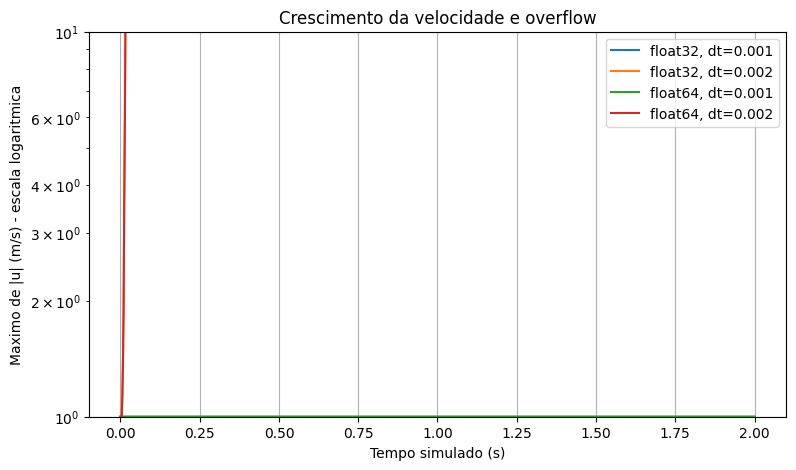

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def simular(dt, tipo=np.float32, passos=2000, pontos=21):
  """Simula difusao de velocidade e detecta falhas."""
  H = 0.01

  nu = 1e-4
  y = np.linspace(0, H, pontos)
  dy = H / (pontos - 1)

  # Coeficientes no tipo numerico escolhido.
  r = tipo(nu * dt / dy**2)
  dois = tipo(2)

  # Fluido parado e placa em y=0 em movimento.
  u = np.zeros(pontos, dtype=tipo)
  u[0] = tipo(1)
  tempos = [0.0]

  maximos = [float(np.max(np.abs(u)))]
  falha = None


  # Transforma avisos numericos em excecoes.
  with np.errstate(over="raise", invalid="raise"):
    for passo in range(1, passos + 1):
      try:
        novo = u.copy()
        # Atualiza o interior e preserva as paredes.
        novo[1:-1] = (
            u[1:-1]
            + r * (
                u[2:] - dois * u[1:-1] + u[:-2]
            )
        )
      except FloatingPointError as erro:
        falha = passo
        print(
            f"dt={dt}, {tipo.__name__}: "
            f"falha no passo {passo}, "
            f"t={passo * dt:.4f} s - {erro}"
        )
        break
      u = novo
      tempos.append(passo * dt)
      maximos.append(float(np.max(np.abs(u))))
  if falha is None:
    print(
        f"dt={dt}, {tipo.__name__}: "
        f"{passos} passos sem overflow."
    )
  return {
      "y": y,
      "u": u,
      "tempos": tempos,
      "maximos": maximos,
      "r": float(r),
      "falha": falha,
  }

print("Maior float32:", np.finfo(np.float32).max)
print("Maior float64:", np.finfo(np.float64).max)

H = 1.0 # Definindo a variavel H
resultados = {}
for tipo in (np.float32, np.float64):
  for dt in (0.001, 0.002):
    nome = f"{tipo.__name__}, dt={dt}"
    resultados[nome] = simular(dt, tipo)

plt.figure(figsize=(9, 5))
for nome, resultado in resultados.items():
  plt.semilogy(
      resultado["tempos"],
      resultado["maximos"],
      label=nome
  )
plt.xlabel("Tempo simulado (s)")
plt.ylabel("Maximo de |u| (m/s) - escala logaritmica")
plt.title("Crescimento da velocidade e overflow")
plt.grid(True)
plt.legend()
plt.show()

# **Atividades propostas:**
1. Verificação da estabilidade.
Calcule ∆y, ∆tmax e r para os casos A e B. Classifique cada caso como estável ou instável antes de executar o programa.
2. Detecção de overflow.
Execute os quatro testes, combinando os dois passos de tempo com os tipos float32 e
float64.
Construa uma tabela contendo: tipo numérico, passo de tempo, valor de r, ocorrência de
overflow e iteração da falha, quando houver.

3. Interpretação física.
Analise o gráfico da maior velocidade em módulo ao longo do tempo. Explique por que o
crescimento observado no caso instável não representa o comportamento físico esperado.

4. Capacidade de representação.
Compare os resultados com float32 e float64. A mudança de tipo numérico elimina a
instabilidade? Justifique a diferença no número de passos até a falha.
5. Refinamento da malha.
Utilize 41 pontos, passando pontos=41 para a função, e mantenha inicialmente ∆t =
0,001 s.
Calcule o novo espaçamento e o novo limite de estabilidade. Execute a simulação e explique
o resultado.
Em seguida, escolha um passo de tempo abaixo do novo limite e repita o teste.
6. Verificação do perfil de velocidade.
Para uma execução estável e suficientemente longa, represente graficamente o perfil final
de velocidade e compare com a solução estacionária:
uest(y) = U
(︂
1 −
y
H
)︂
.
Essa expressão descreve o regime estacionário, e não todo o transiente.
Calcule a diferença máxima em relação ao perfil estacionário:

E∞ = max
i
|ui − uest(yi)| .

Discuta se o tempo simulado foi suficiente para aproximar o regime estacionário. Essa
diferença pode incluir o efeito de um transiente ainda não concluído.


7. Conclusão.
Explique a relação entre refinamento da malha, passo de tempo, instabilidade numérica e
overflow. Indique qual alteração corrigiu a causa da falha nesta simulação.

## Questão 1:

### Caso A

$$
\Delta t_A=0,001\text{ s}
$$


$$
r_A=\frac{\nu\Delta t_A}{\Delta y^2}
$$

$$
r_A=
\frac{(10^{-4})(0,001)}
{(0,0005)^2}
$$

$$
r_A=
\frac{10^{-7}}{2,5\times10^{-7}}
$$

$$
{r_A=0,4}
$$

Comparando coma condição:

$$
r\leq0,5
$$

Como:

$$
0,4\leq0,5
$$

Resultado: **Estável**


### Caso B

$$
\Delta t_B=0,002\text{ s}
$$

Então:

$$
r_B=\frac{\nu\Delta t_B}{\Delta y^2}
$$

$$
r_B=
\frac{(10^{-4})(0,002)}
{(0,0005)^2}
$$

$$
r_B=
\frac{2\times10^{-7}}
{2,5\times10^{-7}}
$$

$$
{r_B=0,8}
$$

Comparando:

$$
0,8>0,5
$$

Resultado: **Instável**


In [9]:
# Executa os quatro testes combinando dois passos de tempo com float32 e float64
resultados = {}

for tipo in (np.float32, np.float64):
    for dt in (0.001, 0.002):
        nome = f"{tipo.__name__}, dt={dt}"
        print(f"\n--- Executando: {nome} ---")
        resultados[nome] = simular(dt, tipo)


--- Executando: float32, dt=0.001 ---
dt=0.001, float32: 2000 passos sem overflow.

--- Executando: float32, dt=0.002 ---
dt=0.002, float32: falha no passo 121, t=0.2420 s - overflow encountered in subtract

--- Executando: float64, dt=0.001 ---
dt=0.001, float64: 2000 passos sem overflow.

--- Executando: float64, dt=0.002 ---
dt=0.002, float64: falha no passo 917, t=1.8340 s - overflow encountered in add


## Questão 2:

### Tabela de Resultados dos Testes

| Tipo Numérico | Passo de Tempo (s) | r | Ocorreu Overflow? | Iteração da Falha |
|---------------|-------------------|-----|-------------------|-------------------|
| float32 | 0,001 | 0,4 | Não | - |
| float32 | 0,002 | 0,8 | Sim | 121 |
| float64 | 0,001 | 0,4 | Não | - |
| float64 | 0,002 | 0,8 | Sim | 917|

**Observações:**
- Os casos estáveis (r = 0,4) não apresentaram overflow para nenhum tipo numérico
- Os casos instáveis (r = 0,8) apresentaram overflow para ambos os tipos
- O float32 falhou em menos iterações que o float64 devido à menor capacidade de representação

### Questão 3:

O gráfico mostra que nos casos estáveis (r = 0,4), a velocidade máxima permanece em valores físicos (≤ 1 m/s), tendendo ao regime estacionário.

Para r=0.8, é instável e a velocidade máxima cresce exponencialmente, o que ultrapassa o valor dísico de U = 1m/s, e causa overflow


Isso não representa o comportamento físico porque para a equação de difusão, a solução deve satisfazer 0 ≤ u ≤ U, o sistema também não possui fontes de energia para acelerar o fluído além da velocidade da placa, e a velocidade dissipa a energia, não amplifica ela.

### Questão 4:

A mudança do tipo numérico não elimina a instabilidade, pois é um problema matemático, não de representação. O float64 demora mais para falhar, isso porque ele tem uma maior faixa de representação, mas ainda sim o overflow acontece.


### Questão 5:

In [13]:
# Teste com 41 pontos
print("=== Teste com 41 pontos ===")

# Caso instável com dt = 0.001
print("\n--- dt = 0.001 ---")
resultado_41_instavel = simular(dt=0.001, pontos=41, passos=2000)

# Caso estável com dt = 0.0002
print("\n--- dt = 0.0002 ---")
resultado_41_estavel = simular(dt=0.0002, pontos=41, passos=2000)

=== Teste com 41 pontos ===

--- dt = 0.001 ---
dt=0.001, float32: falha no passo 56, t=0.0560 s - overflow encountered in multiply

--- dt = 0.0002 ---
dt=0.0002, float32: 2000 passos sem overflow.


dt=0.0002, float64: 5000 passos sem overflow.


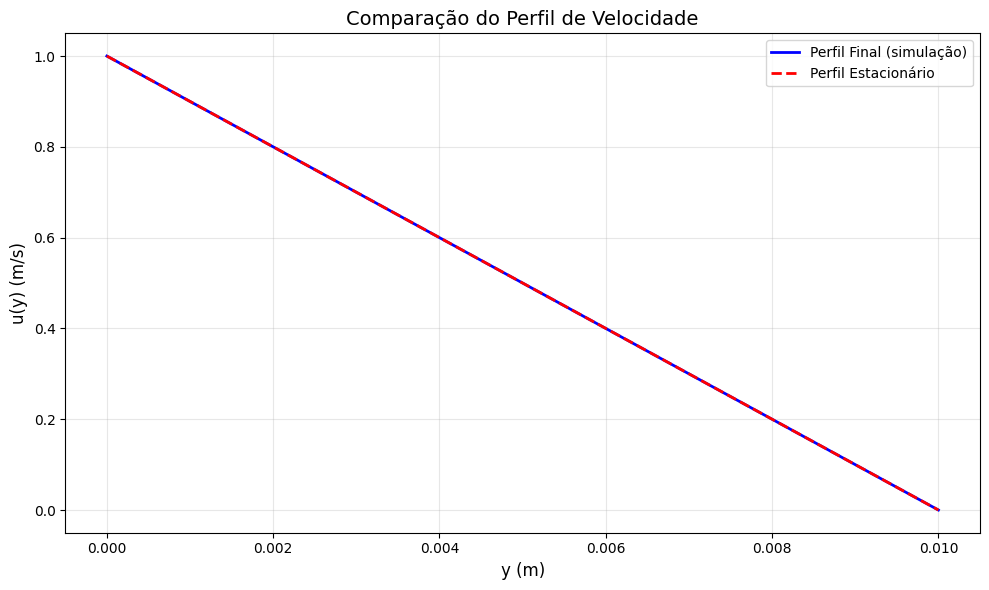

Erro máximo em relação ao perfil estacionário: E∞ = 0.000033


In [14]:
# executa uma simulação estável com 41 pontos e dt = 0.0002
resultado_estavel = simular(dt=0.0002, tipo=np.float64, passos=5000, pontos=41)


U = 1
H = 0.01
y = resultado_estavel["y"]
u_est = U * (1 - y/H)

plt.figure(figsize=(10, 6))
plt.plot(y, resultado_estavel["u"], 'b-', linewidth=2, label='Perfil Final (simulação)')
plt.plot(y, u_est, 'r--', linewidth=2, label='Perfil Estacionário')
plt.xlabel('y (m)', fontsize=12)
plt.ylabel('u(y) (m/s)', fontsize=12)
plt.title('Comparação do Perfil de Velocidade', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

E_inf = np.max(np.abs(resultado_estavel["u"] - u_est))
print(f"Erro máximo em relação ao perfil estacionário: E∞ = {E_inf:.6f}")

## Questão 6:


**Solução estacionária:**
$$u_{est}(y) = U(1 - y/H)$$

**Erro máximo:**
$$E_{\infty} = \max_i |u_i - u_{est}(y_i)|$$



1. **O tempo simulado foi suficiente?**
   - O tempo característico de difusão é $t_{diff} ≈ H^2/ν = 0,01²/10⁻⁴ = 1$ s
   - A simulação com t = 5000 × 0,0002 = 1,0 s é comparável ao tempo característico
   - Para atingir regime estacionário, normalmente são necessários alguns tempos característicos

2. **Fatores que afetam a diferença:**
   - Transiente ainda não concluído
   - Erros de discretização
   - Condições de contorno

3. **Interpretação do erro:**
   - Erro pequeno → simulação próxima do estacionário
   - Erro significativo → transiente ainda ativo

## Questão 7:


**1. Refinamento da malha (Δy):**
- Ao refinar a malha (diminuir Δy), Δt_max diminui (∝ Δy²). É necessário reduzir Δt proporcionalmente para manter a estabilidade. Malhas mais finas exigem passos de tempo menores

**2. Instabilidade Numérica:**
- Ocorre quando r > 1/2. Caracterizada por crescimento exponencial não-físico. É um problema da discretização, não da representação

**3. Overflow:**
- Consequência da instabilidade, não sua causa. Ocorre quando os valores crescem além da capacidade de representação. Tipo numérico afeta quando, não se, ocorre

### Correção da Falha

**Alteração que corrigiu a simulação:**
Reduzir o passo de tempo para Δt ≤ Δy²/(2ν), garantindo r ≤ 1/2.


In [15]:
print("\n" + "="*80)
print("TABELA RESUMO DE RESULTADOS")
print("="*80)

print(f"{'Tipo':<12} {'dt (s)':<12} {'r':<10} {'Overflow':<12} {'Iteração':<10} {'Observação':<20}")
print("-"*80)

for nome, resultado in resultados.items():
    tipo, dt = nome.split(", dt=")
    r = resultado["r"]
    falha = resultado["falha"]

    if falha is None:
        overflow = "Não"
        iteracao = "-"
        obs = "Estável"
    else:
        overflow = "Sim"
        iteracao = str(falha)
        obs = "Instável"

    print(f"{tipo:<12} {dt:<12} {r:<10.4f} {overflow:<12} {iteracao:<10} {obs:<20}")


TABELA RESUMO DE RESULTADOS
Tipo         dt (s)       r          Overflow     Iteração   Observação          
--------------------------------------------------------------------------------
float32      0.001        1.6000     Sim          56         Instável            
float32      0.002        3.2000     Sim          38         Instável            
float64      0.001        1.6000     Sim          426        Instável            
float64      0.002        3.2000     Sim          291        Instável            
